In [1]:
import string
from random import random

import matplotlib.pyplot as plt
import torch
from models import *

data = open('names.txt', 'r').read().splitlines(keepends=False)
print(data[:5])

['emma', 'olivia', 'ava', 'isabella', 'sophia']


In [2]:
bigram = Bigram()
bigram.fit(data)

In [3]:
bigram.make(5)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [4]:
bigram.loss(data)

2.4543561935424805

In [2]:
generator = torch.Generator().manual_seed(1234)
nn = NN(generator=generator)

nn.fit(data)

Loss=2.4627


In [3]:
generator = torch.Generator().manual_seed(1234)
nn.make(generator=generator)

['kyason.', 'kanana.', 'milaveela.', 'ra.', 'drisan.']

In [27]:
stoi = {s: i+1 for i, s in enumerate(string.ascii_lowercase)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

In [28]:
context_size = 8

def build_datasets(data):
    X, Y = [], []
    for word in data:
        context = [0] * context_size
        for char in word + '.':
            idx = stoi[char]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(42)
random.shuffle(data)

n1 = int(len(data) * 0.8)
n2 = int(len(data) * 0.9)

Xtrain, ytrain = build_datasets(data[:n1])
Xdev, ydev = build_datasets(data[n1:n2])
Xtest, ytest = build_datasets(data[n2:])

In [29]:
vocab_size = len(stoi) # 27
n_embed = 24
n_hidden = 128
kernel_size = 3

g = torch.Generator().manual_seed(2147483647)

model = Sequential([
    Embedding(vocab_size, n_embed),
    Convolution1D(n_embed, n_hidden, kernel_size, generator=g, bias=False), BatchNorm1d(n_hidden), Tanh(), # -2
    Convolution1D(n_hidden, n_hidden, kernel_size, generator=g, bias=False), BatchNorm1d(n_hidden), Tanh(), # -4
    Convolution1D(n_hidden, n_hidden, kernel_size, generator=g, bias=False), BatchNorm1d(n_hidden), Tanh(), # -6
    FlattenConsecutive(2),
    Linear(n_hidden * 2, vocab_size, generator=g, gain=5/3)
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum([p.nelement() for p in parameters]))

for p in parameters:
    p.requires_grad = True

115875


In [30]:
n_epochs = 100_000
batch_size = 32
ud = []
lossi = []

for epoch in range(n_epochs):
    # get batch
    idx = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    x, y = Xtrain[idx], ytrain[idx]

    # forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    # backward pass
    for layer in model.layers:
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if epoch < n_epochs / 2 else 0.05
    for p in parameters:
        p.data += -lr * p.grad

    if epoch % 10000 == 0:
        print(f'{epoch}/{n_epochs} {loss:.4f}')

    with torch.no_grad():
        ud.append([((lr * p.grad).std() / p.data.std()).log10().item() for p in parameters])
        lossi.append(loss.log10().item())
loss

0/100000 3.2670
10000/100000 2.1905
20000/100000 2.1011
30000/100000 1.7475
40000/100000 1.7011
50000/100000 1.8458
60000/100000 1.8490
70000/100000 1.8555
80000/100000 1.7745
90000/100000 1.5602


tensor(2.2974, grad_fn=<NllLossBackward0>)

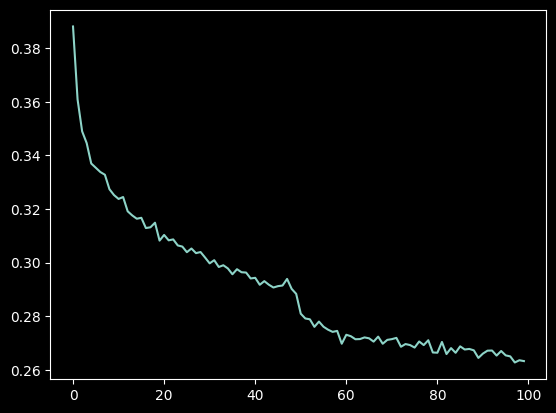

In [31]:
losses = torch.tensor(lossi).view((-1, 1000)).mean(1)
plt.plot(losses)

layer 3 (Tanh): mean: -0.01, std: 0.51, saturated: 12.02%
layer 6 (Tanh): mean: 0.01, std: 0.62, saturated: 15.04%
layer 9 (Tanh): mean: 0.00, std: 0.69, saturated: 10.51%


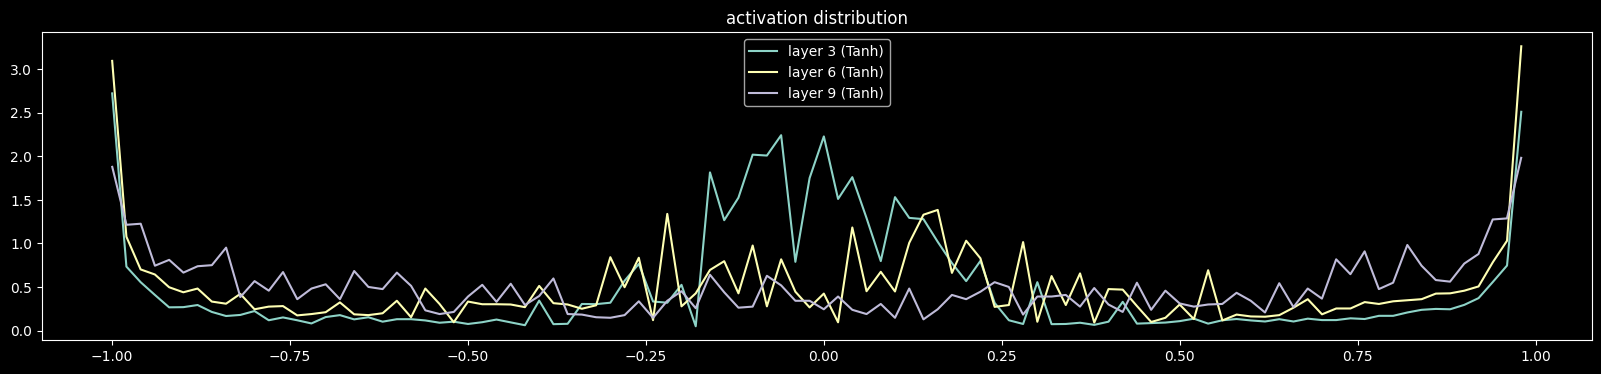

In [14]:
import histograms as H

H.activation_dist(model.layers)

Layer 3 (Tanh): mean -0.000000 std: 3.498647e-03
Layer 6 (Tanh): mean +0.000000 std: 2.749781e-03
Layer 9 (Tanh): mean +0.000008 std: 4.034987e-03


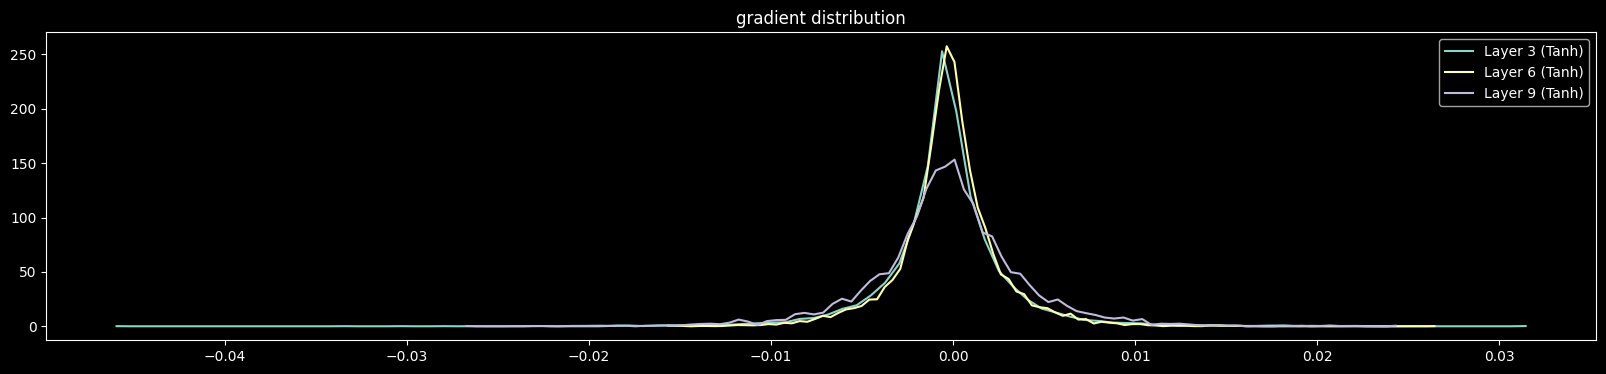

In [15]:
H.gradient_distribution(model.layers)

weight (27, 24) | mean: -0.000000 | std: 1.761336e-02 | grad:data ratio 1.851456e-02
weight (256, 27) | mean: +0.000000 | std: 2.144490e-02 | grad:data ratio 1.417632e-01


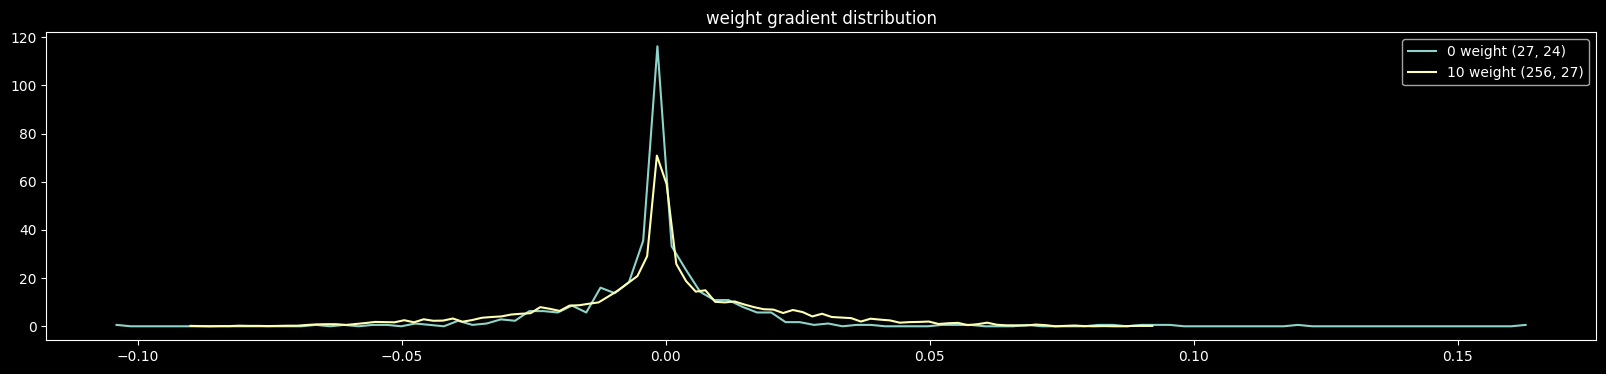

In [16]:
H.weight_gradient_dist(parameters)

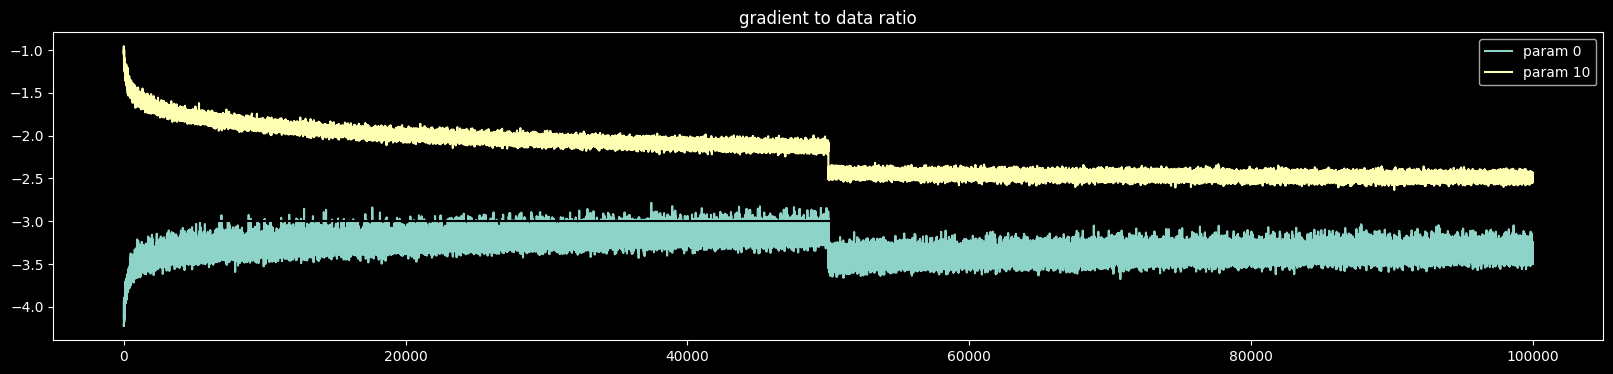

In [17]:
H.grad_data_ratio(parameters, ud)

In [32]:
for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.training = False

with torch.no_grad():
    idx = torch.randint(0, Xdev.shape[0], (batch_size, ))
    x, y = Xdev[idx], ydev[idx]

    # forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

loss

tensor(2.3113)

In [33]:
g = torch.Generator().manual_seed(2147483647 + 10)

def generate(count = 20):
    for layer in model.layers:
        if isinstance(layer, BatchNorm1d):
            layer.training = False

    out = []
    for i in range(count):
        context = [0] * context_size
        res = []

        while True:
            x = torch.tensor([context])
            # forward pass
            logits = model(x)
            probs = F.softmax(logits, dim=1)
            pred = torch.multinomial(probs, 1, generator=g).item()

            res.append(pred)
            context = context[1:] + [pred]

            if pred == 0:
                break

        out.append(''.join(itos[i] for i in res))

    return out

generate()

['carman.',
 'quinley.',
 'fiemji.',
 'remiyah.',
 'cassie.',
 'mahnia.',
 'deviya.',
 'jareti.',
 'nellara.',
 'chaiir.',
 'kaleigh.',
 'hamond.',
 'miquilu.',
 'suliera.',
 'jadii.',
 'wrathon.',
 'jaryn.',
 'xika.',
 'kimora.',
 'meddici.']